# UCI Adult - Questions and Answers
**EPITA – MSc Artificial Intelligence Systems (AIS)**  
**Spark & Python for Big Data AIS S2 F25**

**Students:**
- TRUONG Kim Tan
- LE Linh Long
- Farouk RAHAL

---

## Question 1: Why is it dangerous to blindly drop all rows containing $"?"$ in this specific dataset?

### Reason 1:

Because these missing rows are not random. In the UCI Adult dataset, the $"?"$ characters appear in three specific columns: `workclass` ($6%$), `occupation` ($6%$), and `native-country` ($2%$). Also, from exploring the dataset, we found out that when `workclass` is missing, `occupation` is nearly always missing as well. 
The rows with missing values correlate with attributes such as `race` and `sex`, making deletion a biased sampling method rather than a neutral cleaning step.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load the data
file_path = './adult.csv'
df = pd.read_csv(file_path)

print("1: The patterns of '?' values")

# Check missing values '?'
missing_mask = df.apply(lambda x: x == '?')
missing_counts = missing_mask.sum()
missing_pct = (missing_counts / len(df) * 100).round(2)

print("Missing value vounts (represented as '?'):")
print(pd.DataFrame({'Count': missing_counts, 'Percentage': missing_pct}))

# Check for simultaneous missingness in workclass and occupation
both_missing = ((df['workclass'] == '?') & (df['occupation'] == '?')).sum()
workclass_missing = (df['workclass'] == '?').sum()
occupation_missing = (df['occupation'] == '?').sum()

print(f"Simultaneous Missingness Analysis:")
print(f"  Workclass missing: {workclass_missing:,} ({workclass_missing/len(df)*100:.2f}%)")
print(f"  Occupation missing: {occupation_missing:,} ({occupation_missing/len(df)*100:.2f}%)")
print(f"  Both missing together: {both_missing:,} ({both_missing/len(df)*100:.2f}%)")
print(f"  Overlap rate: {both_missing/max(workclass_missing, occupation_missing)*100:.1f}%")


1: The patterns of '?' values
Missing value vounts (represented as '?'):
                Count  Percentage
age                 0        0.00
workclass        1836        5.64
fnlwgt              0        0.00
education           0        0.00
education.num       0        0.00
marital.status      0        0.00
occupation       1843        5.66
relationship        0        0.00
race                0        0.00
sex                 0        0.00
capital.gain        0        0.00
capital.loss        0        0.00
hours.per.week      0        0.00
native.country    583        1.79
income              0        0.00
Simultaneous Missingness Analysis:
  Workclass missing: 1,836 (5.64%)
  Occupation missing: 1,843 (5.66%)
  Both missing together: 1,836 (5.64%)
  Overlap rate: 99.6%


In [13]:

# Replace '?' with NaN for proper handling
df_clean = df.replace('?', np.nan)

# Create binary income indicator
df_clean['income_binary'] = (df_clean['income'] == '>50K').astype(int)

# Identify rows with missing workclass or occupation
missing_mask = df_clean['workclass'].isna() | df_clean['occupation'].isna()
print(f"Total rows with missing workclass or occupation: {missing_mask.sum()}")
print(f"Percentage: {missing_mask.sum()/len(df_clean)*100:.2f}%")

# Missingness analyzation
print("\n")
print("*"*70)
print("Missing values by race analyzation")
print("*"*70)
missing_by_race = df_clean.groupby('race').apply(
    lambda x: pd.Series({
        'total': len(x),
        'missing_count': x['workclass'].isna().sum(),
        'missing_pct': x['workclass'].isna().sum()/len(x)*100
    })
).round(2)
print(missing_by_race)

print("\n")
print("*"*70)
print("Missing values by sex analyzation")
print("*"*70)
missing_by_sex = df_clean.groupby('sex').apply(
    lambda x: pd.Series({
        'total': len(x),
        'missing_count': x['workclass'].isna().sum(),
        'missing_pct': x['workclass'].isna().sum()/len(x)*100
    })
).round(2)
print(missing_by_sex)


Total rows with missing workclass or occupation: 1843
Percentage: 5.66%


**********************************************************************
Missing values by race analyzation
**********************************************************************
                      total  missing_count  missing_pct
race                                                   
Amer-Indian-Eskimo    311.0           25.0         8.04
Asian-Pac-Islander   1039.0           65.0         6.26
Black                3124.0          213.0         6.82
Other                 271.0           23.0         8.49
White               27816.0         1510.0         5.43


**********************************************************************
Missing values by sex analyzation
**********************************************************************
          total  missing_count  missing_pct
sex                                        
Female  10771.0          839.0         7.79
Male    21790.0          997.0         4.58


### Reason 2:

As we can see from the plot, the blind deletion approach isn't neutral—it systematically preserves data for white males while discarding records from already underrepresented groups, potentially reinforcing algorithmic bias in downstream models trained on such "cleaned" data.

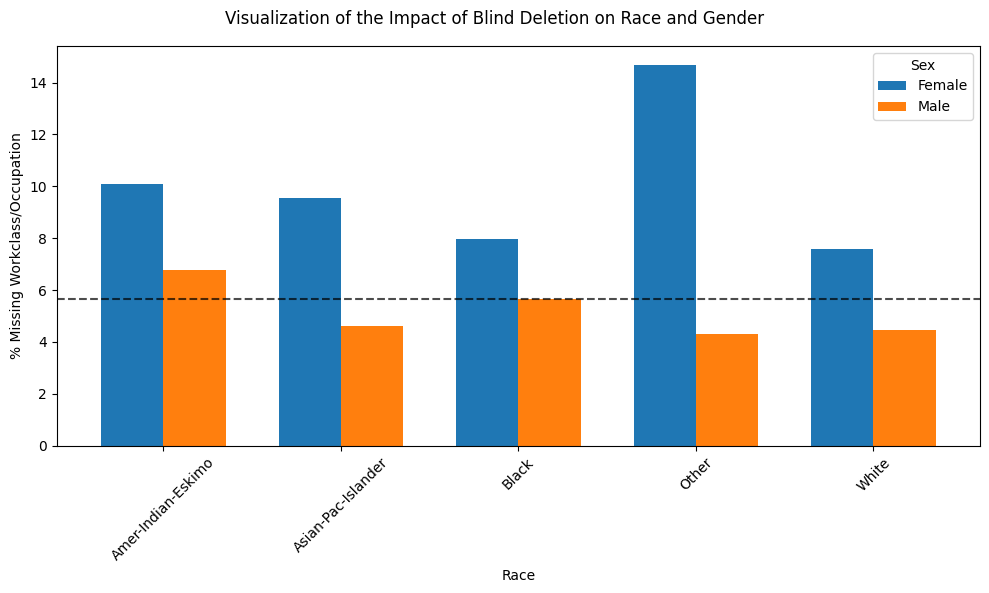

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Visualization of the Impact of Blind Deletion on Race and Gender')

missing_demo = df_clean.groupby(['race', 'sex']).apply(
    lambda x: x['workclass'].isna().sum() / len(x) * 100,
    include_groups=False
).unstack()

missing_demo.plot(kind='bar', ax=ax, width=0.7)
ax.set_ylabel('% Missing Workclass/Occupation')
ax.set_xlabel('Race')
ax.legend(title='Sex', loc='upper right')
ax.tick_params(axis='x', rotation=45)
ax.axhline(y=df_clean['workclass'].isna().sum()/len(df_clean)*100, color='black', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Question 1.2: How did consulting the metadata guide your imputation strategy?

In the case where data is socially sensitive, the missing values actually carry some meaning, and the distribution is highly imbalanced such as `workclass`, `occupation`, and `native_country`, mode imputation would distort demographics. Therefore, to preserve some meaning of **missing**, we applied the method where we create another group $Unknown$ for these datas.

## Question 2: Looking at your Unsupervised Learning results (PCA or KMeans), what hidden patterns did you discover that weren't immediately obvious from the raw data?

Let's take a look at the graph again:

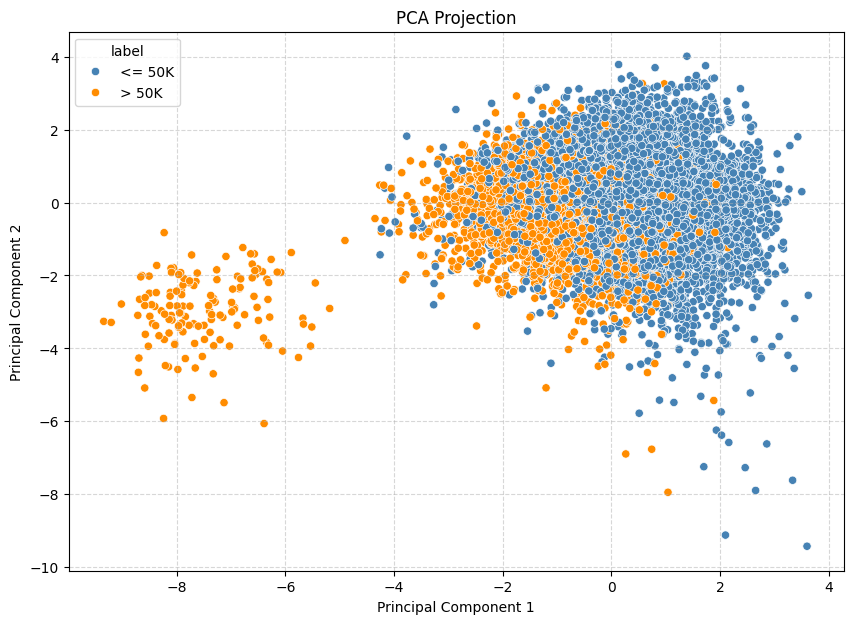

In [15]:
from PIL import Image
Image.open("output.png")

As observed from the graph, we can see:
* A distinct group between people making over 50k from the main cluster. This shows that a specific group of high income people people have a very unique characteristics that set them completely apart from both the general population and other high earners.
* In the center area, there are a heavily overlap between two classes, which is a direct visualization of low explained variance for k = 2, showing that the first two components alone do not capture enough information to cleanly separate the classes.
* At PC2= -6 to -10, there are some anomaly values in both classes, showing that these specific entries have anomalous feature values that pull them far away from the main cluster.

## Question 3: Comparing your Logistic Regression and Random Forest models, which metric (Precision, Recall, or AUC) do you consider most important for this specific business case, and why?

Let's take a look of our label distribution:

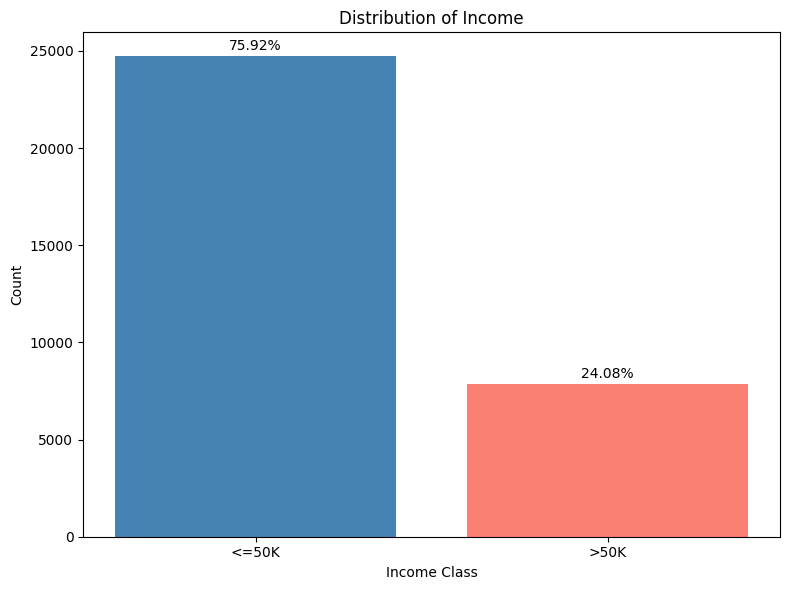

In [26]:
data = {
    'income': ['<=50K', '>50K'],
    'count': [24720, 7841],
    'percentage': [75.91904425539757, 24.080955744602438]
}

df = pd.DataFrame(data)
df = df.sort_values('count', ascending=False)
plt.figure(figsize=(8, 6))
bars = plt.bar(df['income'], df['count'], color=['steelblue', 'salmon'])

plt.xlabel('Income Class')
plt.ylabel('Count')
plt.title('Distribution of Income')

for bar, pct in zip(bars, df['percentage']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 150, f'{pct:.2f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

From the graph we can see a imbalanced data where the <= 50K class takes nearly 76% of the total, which is why high accuracy alone does not accurately reflect the model's performance. A "dumb" model could achieve 76% accuracy by simply guessing the majority class every time without ever identifying the high income people. For that reason, F1 Score and AUC are the most important metrics for business case because they honestly reflect on how well the model handles the minority class.

F1-Score is important because it balances Precision and Recall, forcing the model to be effective at identifying the high income people despite their smaller numbers. Meanwhile, AUC is also critical because it evaluates the model’s ability to distinguish between the two classes across all possible classification thresholds.

## Question 4: Based on your Random Forest feature importance, what actionable advice would you give to someone looking to maximize their chances of earning over $50K?

In [20]:
res = """ 
===== Top 5 Most Important Features =====
                              Feature  Importance
                          net_capital    0.227796
marital_status_ohe_Married-civ-spouse    0.155221
                        education_num    0.150344
             relationship_ohe_Husband    0.095283
                                  age    0.060506
"""
print(res)

 
===== Top 5 Most Important Features =====
                              Feature  Importance
                          net_capital    0.227796
marital_status_ohe_Married-civ-spouse    0.155221
                        education_num    0.150344
             relationship_ohe_Husband    0.095283
                                  age    0.060506



For someone who wants to maximize the chance to earning over $50k, they should consider looking for opportunity that has to maximize the capital gain and minimize it's loss, to achieve a highest net captial. Besides, there seems to be profits from being married a live with a spouse. Finally, education level also plays a crucial role for anyone wants to make over $50k.